# importation

In [1]:
# === Suppress warnings ===
import warnings
warnings.filterwarnings("ignore")

# === Standard libraries ===
import os
import glob
import re

# === Data processing and statistics ===
import numpy as np
import pandas as pd

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Machine Learning ===
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, mean_squared_error
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.model_selection import permutation_test_score
from sklearn.cluster import DBSCAN
from sklearn.metrics import RocCurveDisplay



# function

In [2]:
class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features):
        self.n_features = n_features

    def fit(self, X, y):
        clf = RandomForestClassifier(n_estimators=100, random_state=0)
        clf.fit(X, y)
        importances = clf.feature_importances_
        self.indices_ = np.argsort(importances)[::-1][:self.n_features]
        return self

    def transform(self, X):
        return X[:, self.indices_]

# step1 : prepare the dataset 

In [3]:
df=pd.read_pickle('./milk_10mz.csv')

# Intensity values are not used here, so we remove them from the vector
a=len(df['output_vector'].iloc[0])/3
print(a)
df['output_vector']=df['output_vector'].apply(lambda x : x[int(a):])


df = df.drop_duplicates(subset='echantillon')
df['batch'] = df['batch'].astype('category').cat.codes
df['categ']=df['categ'].apply(lambda x : 0 if x=='c' else 1)


# Batches with fewer than 5 samples or strong categorie imbalance are removed to avoid batch effect bias
df=df[(df['batch']!=1) & (df['batch']!=0)]


X = np.array([np.array(vec) for vec in df['output_vector']]) 
Y=df['categ'].values


X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


630.0


# step2 : find a good number of feature

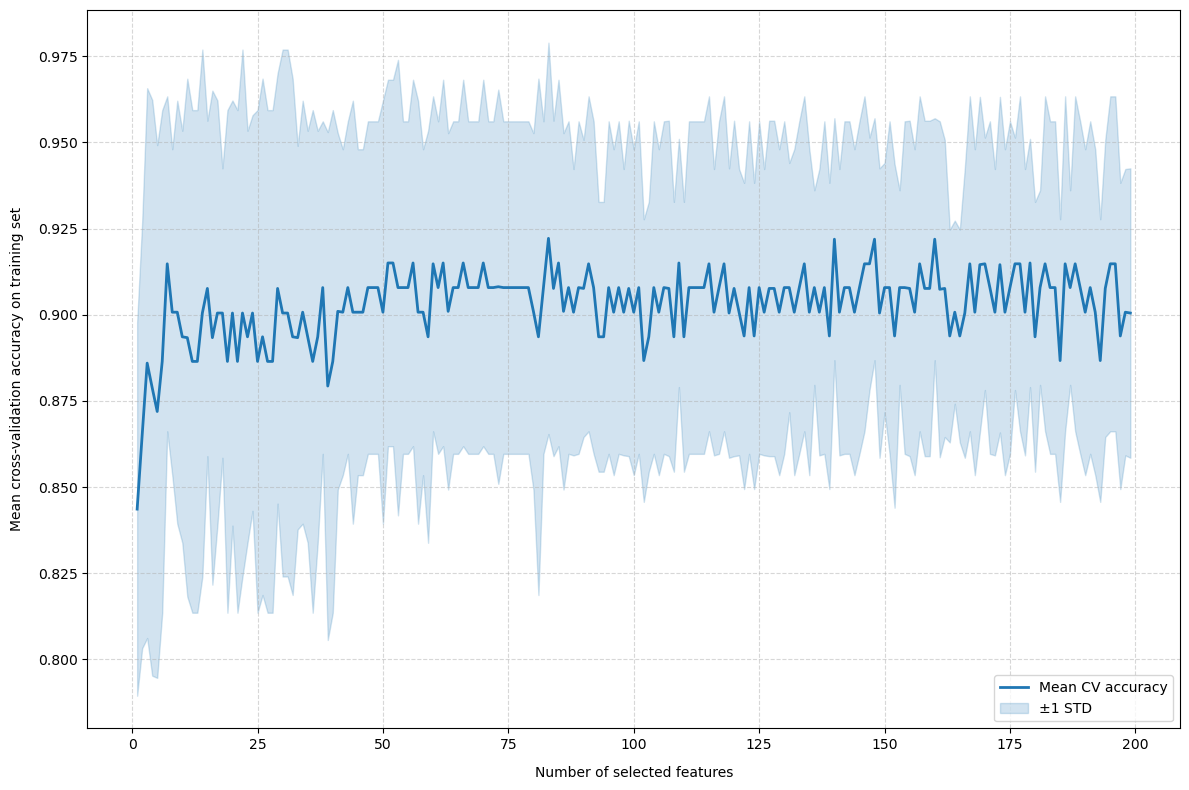

In [4]:
step = 1
max_features = X_train.shape[1]
feature_range = range(step, 200, step)

mean_accuracies = []
std_accuracies = []

for n_features in feature_range:
    pipeline = Pipeline([
    ('feature_selection', TopFeatureSelector(n_features=n_features)),
    ('classification', RandomForestClassifier(n_estimators=100, random_state=0))
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    clf = RandomForestClassifier(n_estimators=100, random_state=0)
    clf.fit(X_train, y_train)
    
    importances = clf.feature_importances_
    sorted_indices = np.argsort(importances)[::-1]
    threshold = importances[sorted_indices[n_features - 1]]  # -1 car index
    
    selector = SelectFromModel(clf, threshold=threshold, prefit=True)
    X_train_reduced = selector.transform(X_train)
    X_test_reduced  = selector.transform(X_test)
    
    rf_reduced = RandomForestClassifier(n_estimators=100, random_state=0)

    mean_accuracies.append(scores.mean())
    std_accuracies.append(scores.std())
    
    rf_reduced.fit(X_train_reduced, y_train)
    y_pred = rf_reduced.predict(X_test_reduced)
    accuracy = accuracy_score(y_test, y_pred)
    
plt.figure(figsize=(12, 8))

feature_range = np.array(list(feature_range))
mean_accuracies = np.array(mean_accuracies)
std_accuracies = np.array(std_accuracies)

plt.plot(feature_range, mean_accuracies, color='tab:blue', linewidth=2, label='Mean CV accuracy')
plt.fill_between(feature_range,
                 mean_accuracies - std_accuracies,
                 mean_accuracies + std_accuracies,
                 color='tab:blue', alpha=0.2, label='±1 STD')
plt.xlabel('Number of selected features', fontsize=10, labelpad=10)
plt.ylabel('Mean cross-validation accuracy on training set', fontsize=10, labelpad=10)
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



# step3 : train the final model & calcule performances

In [5]:
nbOfSelectedFeature=100

Accuracy: 0.9444
[BOOTSTRAP] STD: 0.0378
[BOOTSTRAP] Mean accuracy: 0.9454
[BOOTSTRAP] 95% CI: [0.8611, 1.0000]
[PERMUTATION] p-value: 0.0099
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        27
           1       1.00      0.78      0.88         9

    accuracy                           0.94        36
   macro avg       0.97      0.89      0.92        36
weighted avg       0.95      0.94      0.94        36

[[27  0]
 [ 2  7]]
AUC: 0.9733


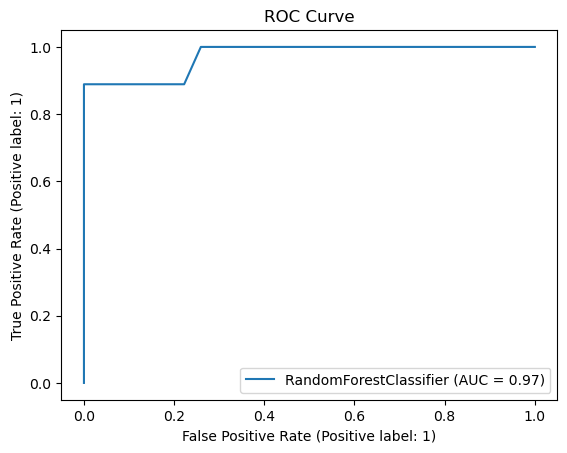

Cross-validated accuracy: 0.9219 ± 0.0386


In [ ]:

clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

importances = clf.feature_importances_

sorted_indices = np.argsort(importances)[::-1]

threshold = importances[sorted_indices[nbOfSelectedFeature]]

selector = SelectFromModel(clf, threshold=threshold, prefit=True)


X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

rf_reduced = RandomForestClassifier(n_estimators=100, random_state=2024)
rf_reduced.fit(X_train_reduced, y_train)

importances2 = rf_reduced.feature_importances_

y_pred = rf_reduced.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

n_iterations = 1000
n_size = len(X_test_reduced)
boot_accuracies = []

for i in range(n_iterations):
    X_sample, y_sample = resample(X_test_reduced, y_test, n_samples=n_size, random_state=i)
    y_pred_sample = rf_reduced.predict(X_sample)
    acc = accuracy_score(y_sample, y_pred_sample)
    boot_accuracies.append(acc)


boot_accuracies = np.array(boot_accuracies)
mean_acc = boot_accuracies.mean()
ci_lower = np.percentile(boot_accuracies, 2.5)
ci_upper = np.percentile(boot_accuracies, 97.5)
std_acc = boot_accuracies.std() 

print(f"[BOOTSTRAP] STD: {std_acc:.4f}")
print(f"[BOOTSTRAP] Mean accuracy: {mean_acc:.4f}")
print(f"[BOOTSTRAP] 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

score, perm_scores, pvalue = permutation_test_score(
    rf_reduced,
    X_test_reduced,
    y_test,
    cv=5,
    n_permutations=100,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42
)

print(f"[PERMUTATION] p-value: {pvalue:.4f}")



print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

y_proba = rf_reduced.predict_proba(X_test_reduced)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.4f}")

RocCurveDisplay.from_estimator(rf_reduced, X_test_reduced, y_test)
plt.title("ROC Curve")
plt.show()

pipeline = Pipeline([
    ('feature_selection', TopFeatureSelector(n_features=nbOfSelectedFeature)),
    ('classification', RandomForestClassifier(n_estimators=100, random_state=2024))
    ])

scores = cross_val_score(pipeline, X_train, y_train, cv=10)
print(f"Cross-validated accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


# step4 result analysis

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

importances = clf.feature_importances_

sorted_indices = np.argsort(importances)[::-1]

threshold = importances[sorted_indices[nbOfSelectedFeature]] 

selector = SelectFromModel(clf, threshold=threshold, prefit=True)


X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)


rf_reduced = RandomForestClassifier(n_estimators=100, random_state=2024)
rf_reduced.fit(X_train_reduced, y_train)


y_pred = rf_reduced.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

selected_features_indices = selector.get_support(indices=True)

print(f"index of selected features : {selected_features_indices}")


In [ ]:
DiscriminativeBinNumberSelected=6
print(DiscriminativeBinNumberSelected)

# For example, we analyze the bin number show in the main paper
# You can change this value according to the discriminative bin numbers mentioned in the paper.
#
# Note that the vector is composed as follows:
# - first: the m/z (mass-to-charge) values up to a given index a,
# - and finally : the RT (retention time) values.
#
# So, for example, if a < selected_features_indices[1]
# it means that selected_features_indices[1] corresponds to an RT value.
# Therefore, to plot RT versus m/z, the user must select:
#   index_2 = selected_features_indices[1] - a


index_1 = selected_features_indices[DiscriminativeBinNumberSelected]
index_2 = selected_features_indices[DiscriminativeBinNumberSelected] + int(a)


In [ ]:

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 10
})

#on overall dataset, that can be reduce to only training or testing
feature_values_1 = [x[index_1] for x in df['output_vector']]
feature_values_2 = [x[index_2] for x in df['output_vector']]

# unnormalization
start_time = 2
end_time = 16
mz_min = 100
mz_max = 1000

feature_values_2 = [(val * (end_time - start_time)) + start_time for val in feature_values_2]
feature_values_1 = [(val * (mz_max - mz_min)) + mz_min for val in feature_values_1]

index_1_name = 'm/z'
index_2_name = 'Retention time (minute)'

y_train2 = ['Organic' if x == 1 else 'Conventional' for x in Y]

df_plot = pd.DataFrame({
    f'{index_1_name}': feature_values_1,
    f'{index_2_name}': feature_values_2,
    'Category': y_train2
})

plt.figure(figsize=(14, 10)) 
scatter = sns.scatterplot(
    data=df_plot,
    x=index_1_name,
    y=index_2_name,
    hue='Category',
    palette='tab10',
    s=120,
    edgecolor='k',
    alpha=0.8
)

plt.xlabel(index_1_name, labelpad=14)
plt.ylabel(index_2_name, labelpad=14)

plt.legend(title='Category', loc='lower left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

def plot_inverted_histogram(index, X_train, y_train,type):
    selected_feature_values = [x[index] for x in X_train]
    if type=='mz':
        range_mz = mz_max - mz_min
        selected_feature_values=[(value * range_mz) + mz_min for value in selected_feature_values]
    else:    
        range_time = end_time - start_time
        selected_feature_values=[(value * range_time) + start_time for value in selected_feature_values]
    y_train = ['Organic' if x == 1 else 'Conventional' for x in y_train]
    df_plot = pd.DataFrame({
        'Feature': selected_feature_values,
        'Category': y_train
    })
    print(df_plot[df_plot['Feature']>137]['Category'].value_counts())
    plt.rcParams.update({'font.size': 10})
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_plot, x='Feature', hue='Category', multiple='stack', bins=50)
    plt.gca().invert_yaxis()
    plt.xlabel('m/z')
    plt.ylabel('Frequency')
    plt.yticks(rotation=45)  
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_inverted_histogram(index_1,df['output_vector'], df['categ'],'mz')



In [ ]:
data=np.array(feature_values_1)
X = np.array(feature_values_1).reshape(-1, 1)

db = DBSCAN(eps=0.01, min_samples=3).fit(X)  # eps est la tolérance (à ajuster)
labels = db.labels_

clusters = {}
for label in np.unique(labels):
    if label == -1:
        continue  # -1 = bruit, on ignore
    cluster_data = data[labels == label]
    mean = np.mean(cluster_data)
    std = np.std(cluster_data)
    std_ppm = (std / mean) * 1e6
    clusters[label] = {
        "count": len(cluster_data),
        "mean": mean,
        "std": std,
        "std_ppm": std_ppm
    }

df2 = pd.DataFrame.from_dict(clusters, orient='index')
df2.index.name = "Cluster"
print(df2)

In [ ]:
borne_min = 138
borne_max = 139
feature_values_1=np.array(feature_values_1)
y_train2 = np.array(y_train2)
valeurs_filtrees = feature_values_1[(feature_values_1 >= borne_min) & (feature_values_1 <= borne_max)]
indices_dans_borne = np.where((feature_values_1 >= borne_min) & (feature_values_1 <= borne_max))[0]
print(len(valeurs_filtrees))
moyenne = np.mean(valeurs_filtrees)
ecart_type = np.std(valeurs_filtrees)
print("Moyenne :", moyenne)
print("Écart-type :", ecart_type)
categories_dans_borne = y_train2[indices_dans_borne]
counts = pd.Series(categories_dans_borne).value_counts()
print("Comptage des catégories dans la plage :")
print(counts)

In [ ]:
#process can be redo for any other bin, on test/train/overall dataset, or with max intensity of the given Bin